<a href="https://colab.research.google.com/github/Esthernakawombe/Esther-Nakawombe-Final-Presentation/blob/main/Esther_Nakawombe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns

from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
xls = pd.ExcelFile("D:\\Ted\\Interest_rates.xlsx")
df = pd.read_excel(xls, 'Daily Interbank Rates')
df = df.iloc[3:]
df.head()

,Back to the Table of Contents,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
3,NaN,NaN,Date,Overnight (%),7-day (%),Overall (%),NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,2012-01-02 00:00:00,27.2,30.75,30.42,NaN,NaN,NaN,NaN
6,NaN,NaN,2012-01-03 00:00:00,26.62,30.96,28.32,NaN,NaN,NaN,NaN
7,NaN,NaN,2012-01-04 00:00:00,28.14,30.59,29.48,NaN,NaN,NaN,NaN


In [ ]:
#df.info()
df = df.drop(columns=['Back to the Table of Contents', 'Unnamed: 1', 'Unnamed: 6'
                      ,'Unnamed: 7','Unnamed: 8','Unnamed: 9'], axis=1)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3686 entries, 3 to 3688
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 2  3551 non-null   object
 1   Unnamed: 3  3509 non-null   object
 2   Unnamed: 4  3431 non-null   object
 3   Unnamed: 5  3551 non-null   object
dtypes: object(4)
memory usage: 115.3+ KB


In [ ]:
df.dropna(inplace=True)
df = df.rename(columns={'Unnamed: 2':'Date', 'Unnamed: 3':'Overnight', 'Unnamed: 4':'7_Day', 'Unnamed: 5':'Overall'})
df = df.iloc[1:]
df.head()

,Date,Overnight,7_Day,Overall
5,2012-01-02 00:00:00,27.2,30.75,30.42
6,2012-01-03 00:00:00,26.62,30.96,28.32
7,2012-01-04 00:00:00,28.14,30.59,29.48
8,2012-01-05 00:00:00,26.8,28.26,27.46
9,2012-01-09 00:00:00,29.0,29.25,29.24


In [ ]:

df['Overall'] = df['Overall'].apply(pd.to_numeric)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Overnight'] = pd.to_numeric(df['Overnight'], errors='coerce').fillna(0)
df['7_Day'] = pd.to_numeric(df['7_Day'], errors='coerce').fillna(0)
#df['7_Day'] = df['7_Day'].apply(pd.to_numeric)
#df['Overnight'] = df['Overnight'].str.replace("-",'0.00')
#df['7_Day'] = df['7_Day'].str.replace('-','0.00')
#df = df.dropna(subset=['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3393 entries, 5 to 3686
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       3393 non-null   datetime64[ns]
 1   Overnight  3393 non-null   float64       
 2   7_Day      3393 non-null   float64       
 3   Overall    3393 non-null   float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 132.5 KB


Creating lags (1 and 2 months)

In [ ]:
df['rate_lag1'] = df['Overall'].shift(1)
df['rate_lag2'] = df['Overall'].shift(2)

In [ ]:
df.head()

,Date,Overnight,7_Day,Overall
5,2012-01-02,27.20,30.75,30.42
6,2012-01-03,26.62,30.96,28.32
7,2012-01-04,28.14,30.59,29.48
8,2012-01-05,26.80,28.26,27.46
9,2012-01-09,29.00,29.25,29.24


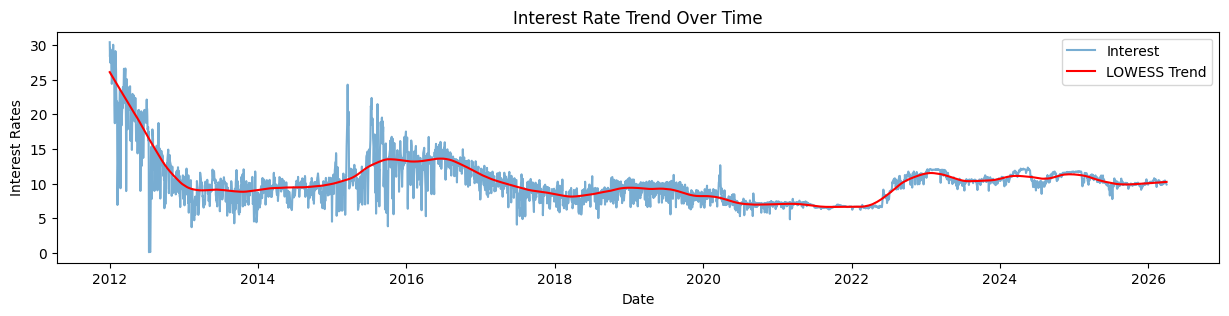

In [ ]:
plt.figure(figsize=(15,3))
plt.plot(df['Date'], df['Overall'], label="Interest", alpha=0.6)

lowess_smoothed = lowess(df['Overall'], df['Date'].astype(np.int64), frac=0.05)
plt.plot(pd.to_datetime(lowess_smoothed[:,0]), lowess_smoothed[:,1],
         color='red', label="LOWESS Trend")

plt.xlabel('Date')
plt.ylabel('Interest Rates')
plt.title('Interest Rate Trend Over Time')
plt.legend()
plt.show()

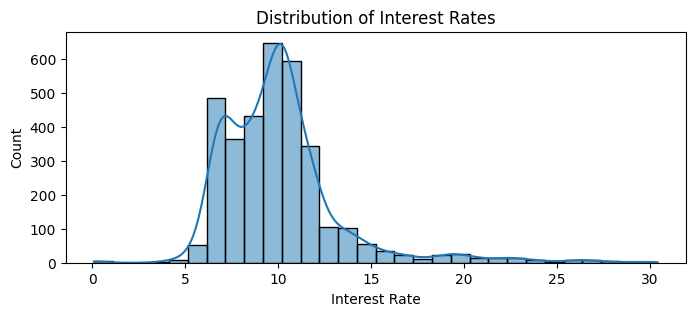

In [ ]:
plt.figure(figsize=(8,3))
sns.histplot(df['Overall'], bins=30, kde=True)
plt.xlabel("Interest Rate")
plt.title("Distribution of Interest Rates")
plt.show()

In [ ]:
df.describe()

,Date,Overnight,7_Day,Overall
count,3393,3393.000000,3393.000000,3393.000000
mean,2018-12-14 10:33:12.572944128,9.718281,11.406200,10.095722
min,2012-01-02 00:00:00,0.000000,0.000000,0.086020
25%,2015-06-25 00:00:00,7.480000,9.630000,7.960000
50%,2018-11-20 00:00:00,9.470652,10.850000,9.850000
75%,2022-05-26 00:00:00,10.850000,12.000000,11.071540
max,2026-03-31 00:00:00,29.862069,31.125000,30.420000
std,NaN,3.229108,3.612626,3.302395


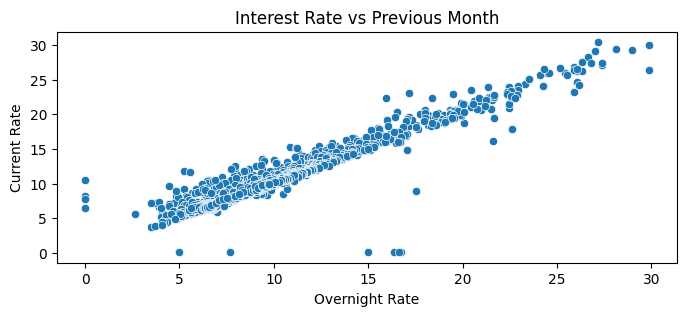

In [ ]:
plt.figure(figsize=(8,3))
sns.scatterplot(x=df['Overnight'], y=df['Overall'])
plt.xlabel("Overnight Rate")
plt.ylabel("Overall Rate")
plt.title("Overnight Rate vs Overall Rate")
plt.show()

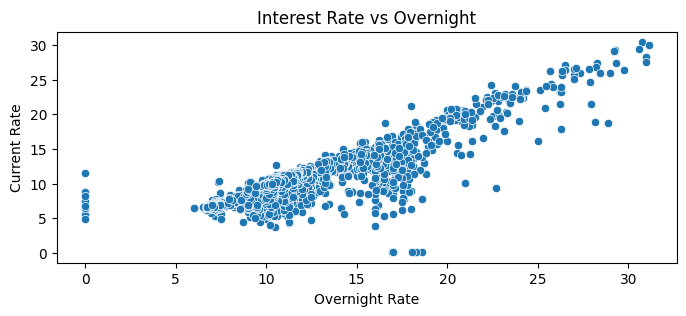

In [ ]:
plt.figure(figsize=(8,3))
sns.scatterplot(x=df['7_Day'], y=df['Overall'])
plt.xlabel("7_Day Rate")
plt.ylabel("Overall Rate")
plt.title("7_Day Rate vs Overall Rate")
plt.show()

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Overall','Overnight','7_Day']].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

NameError: name 'plt' is not defined

In [ ]:
def xyfiles(df):
    y = df.Overall
    X = df.drop(['Overall','Date'], axis=1)
    return X,y


X, y  = xyfiles(df)

In [ ]:
X.head()

,Overnight,7_Day
5,27.20,30.75
6,26.62,30.96
7,28.14,30.59
8,26.80,28.26
9,29.00,29.25


In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

X_valid.shape

(679, 2)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_valid)

In [ ]:
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_valid, y_pred)))
print("Linear Regression R²:", r2_score(y_valid, y_pred))

Linear Regression RMSE: 0.9002009565748997
Linear Regression R²: 0.9319876167139356
